# 04 — Spatial alignment and coverage

## Hygiene
CRS checks for TIGER tracts, study **bbox** (`configs/san_diego.yaml`), and GTFS stop points; projected CRS for distances.

## Analytic core
- **Tracts × bbox:** which San Diego County tracts intersect the study rectangle.
- **Stops × tracts:** point-in-polygon join for stops **inside the bbox** (same rule as `02`).
- **Headways × tracts:** weekday route–direction median headway from `02`’s first-stop proxy, mapped to tracts via any stop on that route.
- **Distance to network:** tract centroid → nearest in-bbox stop (meters, EPSG:3310).

**Exports:** tract-level service table (covariate-ready) + CRS manifest + figures → `artifacts/`; index in `context/structure.md`.

**Prior:** [`03_census_tracts_and_acs.ipynb`](03_census_tracts_and_acs.ipynb)  
**Next:** [`05_osm_pedestrian_network.ipynb`](05_osm_pedestrian_network.ipynb)


In [1]:
from __future__ import annotations

import warnings
from datetime import date
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import Markdown, display
from shapely.geometry import box

warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")


def find_repo_root() -> Path:
    start = Path.cwd().resolve()
    for d in [start, *start.parents]:
        if (d / "configs" / "san_diego.yaml").exists():
            return d
    raise FileNotFoundError("Could not find configs/san_diego.yaml (cd to repo root).")


REPO_ROOT = find_repo_root()
with open(REPO_ROOT / "configs" / "defaults.yaml") as f:
    config = yaml.safe_load(f)
with open(REPO_ROOT / "configs" / "san_diego.yaml") as f:
    config.update(yaml.safe_load(f))

bbox = config["bbox"]
min_lon, min_lat, max_lon, max_lat = bbox
agencies_cfg = config.get("gtfs_agencies", [])
census_cfg = config.get("census", {})
state_fips = str(census_cfg.get("state_fips", config.get("state_fips", "06"))).zfill(2)
county_fips = str(census_cfg.get("county_fips", config.get("county_fips", "073"))).zfill(3)
acs_year = int(census_cfg.get("acs_year", 2023))

TODAY = date.today().isoformat()
ART_TABLES = REPO_ROOT / "artifacts" / "tables"
ART_FIG = REPO_ROOT / "artifacts" / "figures"
ART_TABLES.mkdir(parents=True, exist_ok=True)
ART_FIG.mkdir(parents=True, exist_ok=True)

PROJ_CRS = "EPSG:3310"  # NAD83 / California Albers — meters, good for Southern CA

print(f"REPO_ROOT={REPO_ROOT}")
print(f"bbox={bbox}")
print(f"TODAY={TODAY}  PROJ_CRS={PROJ_CRS}")


REPO_ROOT=C:\Users\sardo\OneDrive\Desktop\Classes\Projects\BayesTransitEquity
bbox=[-117.28, 32.53, -116.93, 33.11]
TODAY=2026-03-29  PROJ_CRS=EPSG:3310


## Load GTFS (same tables as `02`)


In [2]:
GTFS_TABLES = (
    "agency",
    "routes",
    "trips",
    "stops",
    "stop_times",
    "calendar",
    "calendar_dates",
    "shapes",
)


def load_gtfs_feed(extracted_dir: Path) -> dict[str, pd.DataFrame | None]:
    out: dict[str, pd.DataFrame | None] = {}
    for name in GTFS_TABLES:
        p = extracted_dir / f"{name}.txt"
        if not p.exists():
            out[name] = None
            continue
        out[name] = pd.read_csv(p, encoding="utf-8", low_memory=False)
    return out


def stops_in_bbox(stops: pd.DataFrame) -> pd.Series:
    lat = stops["stop_lat"].astype(float)
    lon = stops["stop_lon"].astype(float)
    return (lon >= min_lon) & (lon <= max_lon) & (lat >= min_lat) & (lat <= max_lat)


def weekday_service_ids(calendar: pd.DataFrame | None) -> set:
    if calendar is None or calendar.empty or "monday" not in calendar.columns:
        return set()
    m = calendar["monday"].astype(str).str.strip() == "1"
    return set(calendar.loc[m, "service_id"].astype(str))


def departure_to_seconds(x) -> float:
    if pd.isna(x):
        return np.nan
    parts = str(x).strip().split(":")
    if len(parts) != 3:
        return np.nan
    h, m, s = int(parts[0]), int(parts[1]), float(parts[2])
    return h * 3600 + m * 60 + s


def median_headway_first_stop(
    trips: pd.DataFrame,
    stop_times: pd.DataFrame,
    weekday_ids: set,
    min_gap_s: float = 120.0,
    max_gap_s: float = 10800.0,
) -> pd.DataFrame:
    if trips is None or stop_times is None or not weekday_ids:
        return pd.DataFrame()
    t = trips[trips["service_id"].astype(str).isin(weekday_ids)].copy()
    st = stop_times.merge(t[["trip_id", "route_id", "direction_id"]], on="trip_id", how="inner")
    st = st[st["stop_sequence"].astype(int) == 1].copy()
    st["dep_s"] = st["departure_time"].map(departure_to_seconds)
    st = st.dropna(subset=["dep_s"])
    rows = []
    for (rid, did), g in st.groupby(["route_id", "direction_id"]):
        srt = np.sort(g["dep_s"].values)
        if len(srt) < 2:
            continue
        gaps = np.diff(srt)
        gaps = gaps[(gaps >= min_gap_s) & (gaps <= max_gap_s)]
        if len(gaps) == 0:
            continue
        rows.append(
            {
                "route_id": rid,
                "direction_id": did,
                "median_headway_min": float(np.median(gaps) / 60.0),
                "n_gaps": len(gaps),
            }
        )
    return pd.DataFrame(rows)


feeds: dict[str, dict[str, pd.DataFrame | None]] = {}
for ag in agencies_cfg:
    aid = ag["id"]
    ex = REPO_ROOT / ag["raw_path"] / "extracted"
    if not ex.is_dir():
        raise FileNotFoundError(f"Missing extracted GTFS for {aid}: {ex}")
    feeds[aid] = load_gtfs_feed(ex)
    print(f"Loaded {aid}: {ex.relative_to(REPO_ROOT)}")


Loaded mts: data\raw\gtfs\mts\extracted


Loaded nctd: data\raw\gtfs\nctd\extracted


## TIGER tracts (San Diego County) + study bbox polygon


In [3]:
tiger_dir = REPO_ROOT / "data" / "raw" / "census" / f"tl_{acs_year}_{state_fips}_tract"
shp = tiger_dir / f"tl_{acs_year}_{state_fips}_tract.shp"
if not shp.exists():
    raise FileNotFoundError(f"Missing TIGER shapefile: {shp}")

tracts_all = gpd.read_file(shp)
tracts_sd = tracts_all[
    (tracts_all["STATEFP"].astype(str).str.zfill(2) == state_fips)
    & (tracts_all["COUNTYFP"].astype(str).str.zfill(3) == county_fips)
].copy()
tracts_sd["GEOID"] = tracts_sd["GEOID"].astype(str)

study_bbox_poly = box(min_lon, min_lat, max_lon, max_lat)
bbox_gdf = gpd.GeoDataFrame(geometry=[study_bbox_poly], crs="EPSG:4326")

tracts_sd["intersects_study_bbox"] = tracts_sd.geometry.intersects(study_bbox_poly)
tracts_sd_proj = tracts_sd.to_crs(PROJ_CRS)
tracts_sd["area_km2"] = tracts_sd_proj.geometry.area / 1e6

display(Markdown("### Tracts vs study bbox"))
display(
    pd.DataFrame(
        [
            {"metric": "n_tracts_sd_county", "value": len(tracts_sd)},
            {
                "metric": "n_tracts_intersecting_bbox",
                "value": int(tracts_sd["intersects_study_bbox"].sum()),
            },
        ]
    )
)


### Tracts vs study bbox

,metric,value
0,n_tracts_sd_county,737
1,n_tracts_intersecting_bbox,571


## CRS alignment manifest


In [4]:
crs_manifest = pd.DataFrame(
    [
        {"layer": "tiger_tracts_sd", "crs": str(tracts_sd.crs)},
        {"layer": "study_bbox", "crs": str(bbox_gdf.crs)},
        {"layer": "gtfs_stops_points", "crs": "EPSG:4326"},
        {"layer": "projected_analysis", "crs": PROJ_CRS},
    ]
)
display(Markdown("### CRS manifest"))
display(crs_manifest)

p_crs = ART_TABLES / f"eda__spatial_layers_crs__{TODAY}.csv"
crs_manifest.to_csv(p_crs, index=False)
print(f"Saved: {p_crs.relative_to(REPO_ROOT)}")


### CRS manifest

,layer,crs
0,tiger_tracts_sd,EPSG:4269
1,study_bbox,EPSG:4326
2,gtfs_stops_points,EPSG:4326
3,projected_analysis,EPSG:3310


Saved: artifacts\tables\eda__spatial_layers_crs__2026-03-29.csv


## Spatial join: in-bbox stops → tract


In [5]:
stop_parts = []
for aid, F in feeds.items():
    s = F["stops"]
    if s is None or s.empty:
        continue
    inside = stops_in_bbox(s)
    sub = s.loc[inside, ["stop_id", "stop_lat", "stop_lon"]].copy()
    sub["agency"] = aid
    stop_parts.append(sub)

stops_df = pd.concat(stop_parts, ignore_index=True) if stop_parts else pd.DataFrame()
if stops_df.empty:
    raise RuntimeError("No in-bbox stops found — check GTFS paths and bbox.")

stops_gdf = gpd.GeoDataFrame(
    stops_df,
    geometry=gpd.points_from_xy(stops_df["stop_lon"], stops_df["stop_lat"]),
    crs="EPSG:4326",
)

tracts_for_join = tracts_sd[["GEOID", "geometry"]].copy()
joined = gpd.sjoin(stops_gdf, tracts_for_join, how="left", predicate="within")
miss = joined["GEOID"].isna().sum()
if miss:
    display(Markdown(f"_Note: {miss} in-bbox stops fall outside SD county tract polygons (e.g. ocean / neighbor county)._"))

j2 = joined.dropna(subset=["GEOID"]).copy()
j2["stop_id"] = j2["stop_id"].astype(str)
if j2.empty:
    display(Markdown("_Warning: no in-bbox stops fell inside SD county tract polygons._"))
    stop_counts = pd.DataFrame({"GEOID": tracts_sd["GEOID"].unique()})
    stop_counts["n_stops_mts"] = 0
    stop_counts["n_stops_nctd"] = 0
    stop_counts["n_stops_in_bbox"] = 0
else:
    sc = (
        j2.groupby(["GEOID", "agency"], as_index=False)
        .agg(n_stops=("stop_id", "nunique"))
        .pivot(index="GEOID", columns="agency", values="n_stops")
        .fillna(0)
    )
    for aid, col in (("mts", "n_stops_mts"), ("nctd", "n_stops_nctd")):
        if aid in sc.columns:
            sc = sc.rename(columns={aid: col})
    for col in ("n_stops_mts", "n_stops_nctd"):
        if col not in sc.columns:
            sc[col] = 0
    sc["n_stops_in_bbox"] = sc["n_stops_mts"] + sc["n_stops_nctd"]
    stop_counts = sc.reset_index().astype({"n_stops_mts": int, "n_stops_nctd": int, "n_stops_in_bbox": int})

display(Markdown("### Stop counts per tract (in-bbox stops only)"))
display(stop_counts["n_stops_in_bbox"].describe().to_frame("value"))


C:\Users\sardo\AppData\Local\Temp\ipykernel_7304\1379134744.py:22: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:4326
Right CRS: EPSG:4269

  joined = gpd.sjoin(stops_gdf, tracts_for_join, how="left", predicate="within")


### Stop counts per tract (in-bbox stops only)

,value
count,488.000000
mean,9.071721
std,8.526380
min,1.000000
25%,4.000000
50%,7.000000
75%,11.000000
max,90.000000


## Route–direction headways → tracts (any stop on route)


In [6]:
def stop_to_route_directions(feed: dict, aid: str) -> pd.DataFrame:
    st, tr = feed["stop_times"], feed["trips"]
    if st is None or tr is None or st.empty or tr.empty:
        return pd.DataFrame(columns=["stop_id", "route_id", "direction_id", "agency"])
    m = st.merge(tr[["trip_id", "route_id", "direction_id"]], on="trip_id", how="inner")
    u = m[["stop_id", "route_id", "direction_id"]].drop_duplicates()
    u["agency"] = aid
    u["stop_id"] = u["stop_id"].astype(str)
    return u


srd_parts = [stop_to_route_directions(feeds[a], a) for a in feeds]
srd = pd.concat(srd_parts, ignore_index=True)

hw_frames = []
for aid, F in feeds.items():
    t, st, cal = F["trips"], F["stop_times"], F["calendar"]
    wids = weekday_service_ids(cal)
    hw = median_headway_first_stop(t, st, wids)
    if hw.empty:
        continue
    h = hw.copy()
    h.insert(0, "agency", aid)
    hw_frames.append(h)

hw_all = pd.concat(hw_frames, ignore_index=True) if hw_frames else pd.DataFrame()

if j2.empty:
    tract_route_keys = pd.DataFrame(columns=["GEOID", "agency", "route_id", "direction_id"])
else:
    tract_route_keys = j2.merge(srd, on=["stop_id", "agency"], how="inner")
    tract_route_keys = tract_route_keys[["GEOID", "agency", "route_id", "direction_id"]].drop_duplicates()

if tract_route_keys.empty:
    tract_hw = pd.DataFrame(columns=[
        "GEOID",
        "n_route_directions",
        "n_route_directions_with_headway",
        "min_route_headway_min",
        "mean_route_headway_min",
        "median_route_headway_min",
    ])
elif hw_all.empty:
    tract_hw = (
        tract_route_keys.groupby("GEOID", as_index=False)
        .size()
        .rename(columns={"size": "n_route_directions"})
    )
    tract_hw["n_route_directions_with_headway"] = 0
    tract_hw["min_route_headway_min"] = np.nan
    tract_hw["mean_route_headway_min"] = np.nan
    tract_hw["median_route_headway_min"] = np.nan
else:
    trk = tract_route_keys.merge(
        hw_all,
        on=["agency", "route_id", "direction_id"],
        how="left",
    )

    def _hw_summ(g: pd.DataFrame) -> pd.Series:
        m = g["median_headway_min"]
        return pd.Series(
            {
                "n_route_directions": len(g),
                "n_route_directions_with_headway": int(m.notna().sum()),
                "min_route_headway_min": m.min(),
                "mean_route_headway_min": m.mean(),
                "median_route_headway_min": m.median(),
            }
        )

    tract_hw = trk.groupby("GEOID", group_keys=True).apply(_hw_summ, include_groups=False).reset_index()

display(Markdown("### Tract headway summaries (from routes touching in-bbox stops in tract)"))
if not tract_hw.empty and "min_route_headway_min" in tract_hw.columns:
    display(tract_hw[[c for c in tract_hw.columns if c != "GEOID"]].describe().T)


### Tract headway summaries (from routes touching in-bbox stops in tract)

,count,mean,std,min,25%,50%,75%,max
n_route_directions,488.0,3.868852,4.237218,1.0,2.000000,3.00000,4.0000,33.0
n_route_directions_with_headway,488.0,3.663934,3.862866,1.0,1.000000,2.50000,4.0000,28.0
min_route_headway_min,488.0,18.251025,15.431108,5.0,9.000000,15.00000,20.5000,126.0
mean_route_headway_min,488.0,24.696170,16.116063,7.0,14.333333,20.13125,30.0000,126.0
median_route_headway_min,488.0,23.226947,16.138489,7.0,13.500000,17.00000,29.8125,126.0


## Distance from tract centroid to nearest in-bbox stop (m)


In [7]:
centroids = tracts_sd.copy()
centroids["geometry"] = tracts_sd_proj.geometry.centroid
centroids = centroids.set_geometry("geometry").set_crs(PROJ_CRS, allow_override=True)

stops_proj = stops_gdf.to_crs(PROJ_CRS)
nearest = gpd.sjoin_nearest(
    centroids[["GEOID", "geometry"]],
    stops_proj[["geometry"]],
    how="left",
    distance_col="dist_m",
)
dist_df = nearest.groupby("GEOID", as_index=False).agg(dist_nearest_stop_m=("dist_m", "min"))

display(Markdown("### Nearest-stop distance (tract centroid)"))
display(dist_df["dist_nearest_stop_m"].describe().to_frame("meters"))


### Nearest-stop distance (tract centroid)

,meters
count,737.000000
mean,3394.233017
std,6861.564772
min,12.737586
25%,298.674009
50%,646.358389
75%,2774.733122
max,64533.439540


## Merge ACS attributes (latest `eda__acs_sd_tract_attributes__*.csv`)


In [8]:
base = tracts_sd[
    ["GEOID", "NAME", "intersects_study_bbox", "area_km2"]
].drop_duplicates("GEOID")

out = base.merge(stop_counts, on="GEOID", how="left")
for c in ["n_stops_mts", "n_stops_nctd", "n_stops_in_bbox"]:
    if c not in out.columns:
        out[c] = 0
    out[c] = out[c].fillna(0).astype(int)

out = out.merge(tract_hw, on="GEOID", how="left")
out["n_route_directions"] = out["n_route_directions"].fillna(0).astype(int)
if "n_route_directions_with_headway" in out.columns:
    out["n_route_directions_with_headway"] = out["n_route_directions_with_headway"].fillna(0).astype(
        int
    )

out = out.merge(dist_df, on="GEOID", how="left")

acs_glob = sorted(ART_TABLES.glob("eda__acs_sd_tract_attributes__*.csv"))
if acs_glob:
    acs_path = acs_glob[-1]
    acs_tbl = pd.read_csv(acs_path, dtype={"GEOID": str})
    keep = [c for c in ["GEOID", "poverty_rate", "disadvantage_z", "rel_moe_pop", "B01003_001E"] if c in acs_tbl.columns]
    out = out.merge(acs_tbl[keep], on="GEOID", how="left", suffixes=("", "_acs"))
    print(f"Merged ACS columns from {acs_path.name}")
else:
    print("No eda__acs_sd_tract_attributes__*.csv — run notebook 03 first for ACS merge.")

col_order = [
    "GEOID",
    "NAME",
    "intersects_study_bbox",
    "area_km2",
    "n_stops_in_bbox",
    "n_stops_mts",
    "n_stops_nctd",
    "n_route_directions",
    "n_route_directions_with_headway",
    "min_route_headway_min",
    "mean_route_headway_min",
    "median_route_headway_min",
    "dist_nearest_stop_m",
    "poverty_rate",
    "disadvantage_z",
    "rel_moe_pop",
    "B01003_001E",
]
col_order = [c for c in col_order if c in out.columns]
tract_service = out[col_order].sort_values("GEOID").reset_index(drop=True)

p_svc = ART_TABLES / f"eda__tract_gtfs_service__{TODAY}.csv"
tract_service.to_csv(p_svc, index=False)
print(f"Saved: {p_svc.relative_to(REPO_ROOT)}  (n={len(tract_service)})")

bbox_tracts = tract_service[tract_service["intersects_study_bbox"]]
zero_in_bbox = int((bbox_tracts["n_stops_in_bbox"] == 0).sum())
display(
    Markdown(
        f"### Tracts intersecting bbox with **zero** in-bbox stops: **{zero_in_bbox}** "
        f"of {len(bbox_tracts)} intersecting tracts"
    )
)


Merged ACS columns from eda__acs_sd_tract_attributes__2026-03-29.csv
Saved: artifacts\tables\eda__tract_gtfs_service__2026-03-29.csv  (n=737)


### Tracts intersecting bbox with **zero** in-bbox stops: **83** of 571 intersecting tracts

## Figures


Saved: artifacts\figures\eda__tract_stops_choropleth__2026-03-29.png


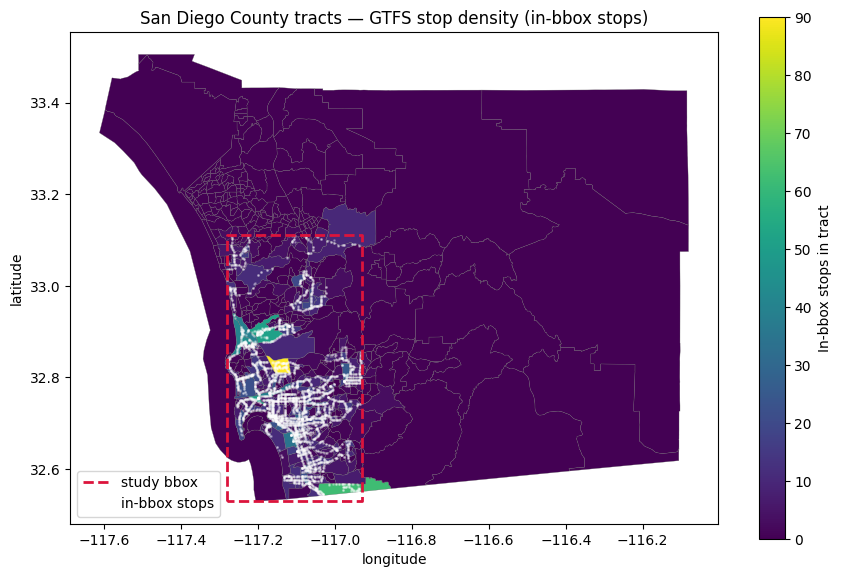

Saved: artifacts\figures\eda__tract_nearest_stop_distance__2026-03-29.png


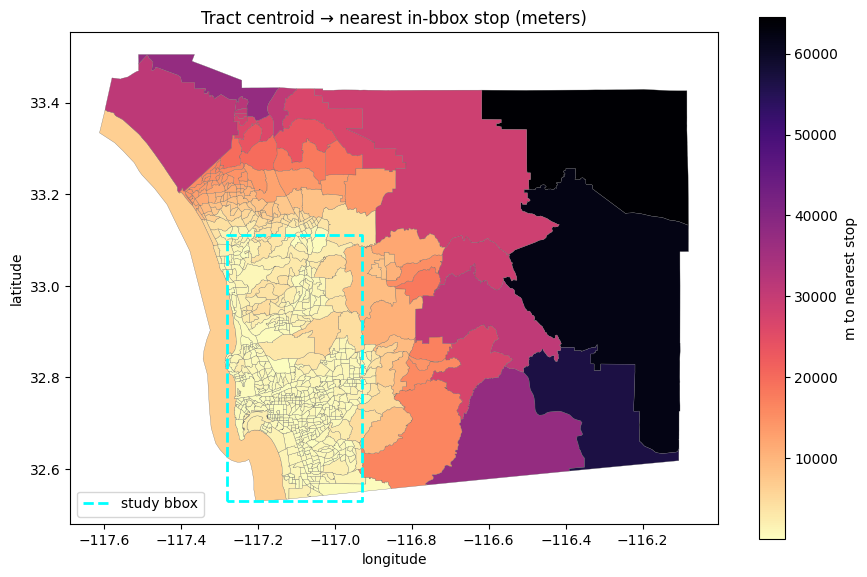

In [9]:
plot_gdf = tracts_sd.merge(
    tract_service[["GEOID", "n_stops_in_bbox"]], on="GEOID", how="left"
)
plot_gdf["n_stops_in_bbox"] = plot_gdf["n_stops_in_bbox"].fillna(0)

fig, ax = plt.subplots(figsize=(9, 9))
plot_gdf.plot(
    column="n_stops_in_bbox",
    ax=ax,
    legend=True,
    cmap="viridis",
    edgecolor="0.4",
    linewidth=0.2,
    legend_kwds={"label": "In-bbox stops in tract", "shrink": 0.6},
    missing_kwds={"color": "lightgrey"},
)
bbox_gdf.boundary.plot(ax=ax, color="crimson", linewidth=2, linestyle="--", label="study bbox")
stops_gdf.plot(ax=ax, markersize=1, color="white", alpha=0.25, label="in-bbox stops")
ax.set_title("San Diego County tracts — GTFS stop density (in-bbox stops)")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.legend(loc="lower left")
plt.tight_layout()
fp1 = ART_FIG / f"eda__tract_stops_choropleth__{TODAY}.png"
fig.savefig(fp1, dpi=200, bbox_inches="tight")
print(f"Saved: {fp1.relative_to(REPO_ROOT)}")
plt.show()

fig2, ax2 = plt.subplots(figsize=(9, 9))
dm = tract_service.dropna(subset=["dist_nearest_stop_m"])
plot_d = tracts_sd.merge(dm[["GEOID", "dist_nearest_stop_m"]], on="GEOID", how="left")
plot_d.plot(
    column="dist_nearest_stop_m",
    ax=ax2,
    legend=True,
    cmap="magma_r",
    edgecolor="0.4",
    linewidth=0.2,
    legend_kwds={"label": "m to nearest stop", "shrink": 0.6},
    missing_kwds={"color": "lightgrey"},
)
bbox_gdf.boundary.plot(ax=ax2, color="cyan", linewidth=2, linestyle="--", label="study bbox")
ax2.set_title("Tract centroid → nearest in-bbox stop (meters)")
ax2.set_xlabel("longitude")
ax2.set_ylabel("latitude")
ax2.legend(loc="lower left")
plt.tight_layout()
fp2 = ART_FIG / f"eda__tract_nearest_stop_distance__{TODAY}.png"
fig2.savefig(fp2, dpi=200, bbox_inches="tight")
print(f"Saved: {fp2.relative_to(REPO_ROOT)}")
plt.show()
